## Weather Data Analyzer

Objective

This project analyzes weather data to explore temperature trends, humidity variations, and other climatic factors using Python.  
The goal is to visualize and summarize key patterns within the dataset to draw meaningful insights about weather behavior.

Tools Used:Python,Pandas,Matplotlib,Seaborn,Scipy  
Environment:Google Colab  
Dataset Source:[Kaggle – Weather Dataset]

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization settings
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
from google.colab import files

print("Upload the weather dataset:")
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Data loaded successfully!")
print("Shape of dataset:", df.shape)

Upload the weather dataset:


Saving weatherHistory.csv to weatherHistory (2).csv
Data loaded successfully!
Shape of dataset: (96453, 12)


Step-1:Dataset Overview

Displaying the first few rows and basic info to understand the data structure.

In [30]:
# Display first few rows
display(df.head())

# Information and column details
print("\nDataset Info:")
df.info()

# Summary statistics
print("\nSummary Statistics:")
display(df.describe(include='all').T)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Formatted Date,96453,96429,2010-08-02 01:00:00.000 +0200,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Summary,96453,27,Partly Cloudy,31733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Precip Type,95936,2,rain,85224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature (C),96453.0,NaN,NaN,NaN,11.932678,9.551546,-21.822222,4.688889,12.0,18.838889,39.905556
Apparent Temperature (C),96453.0,NaN,NaN,NaN,10.855029,10.696847,-27.716667,2.311111,12.0,18.838889,39.344444
Humidity,96453.0,NaN,NaN,NaN,0.734899,0.195473,0.0,0.6,0.78,0.89,1.0
Wind Speed (km/h),96453.0,NaN,NaN,NaN,10.81064,6.913571,0.0,5.8282,9.9659,14.1358,63.8526
Wind Bearing (degrees),96453.0,NaN,NaN,NaN,187.509232,107.383428,0.0,116.0,180.0,290.0,359.0
Visibility (km),96453.0,NaN,NaN,NaN,10.347325,4.192123,0.0,8.3398,10.0464,14.812,16.1
Loud Cover,96453.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 Observations
- The dataset contains continuous variables like Temperature (C), Humidity, and Wind Speed (km/h).  
- It also includes categorical data such as Summary describing weather conditions.  
- The column *Formatted Date* will be converted to a proper datetime format for time-series analysis.


In [31]:
# Convert 'Formatted Date' to datetime and set as index
df['datetime'] = pd.to_datetime(df['Formatted Date'], errors='coerce', utc=True)
df = df.set_index('datetime').sort_index()

# Drop irrelevant or duplicate columns
df = df.drop(columns=['Formatted Date'], errors='ignore')

# Drop duplicates and missing values
df = df.drop_duplicates()
df = df.dropna(subset=['Temperature (C)', 'Humidity'])

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (96424, 11)



#### Data Cleaning Summary
- Converted *Formatted Date* into datetime format and used it as an index.  
- Removed duplicate rows and handled missing values.  
- Ensured temperature and humidity fields are non-null for reliable analysis.


#### Step 2: Data Visualization & Trend Analysis
Now, let's explore patterns and relationships within the data using Seaborn and Matplotlib.

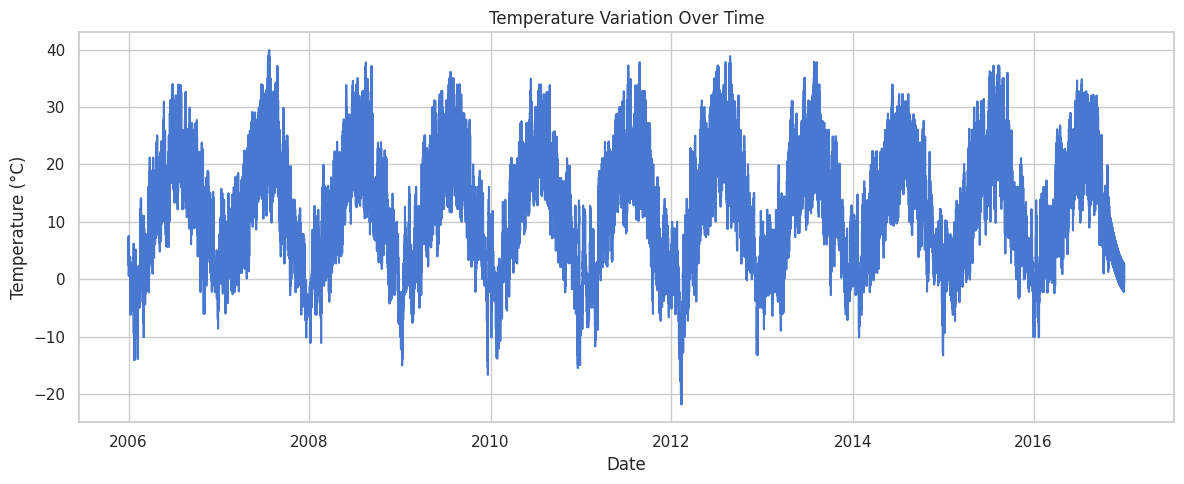

In [32]:
plt.figure(figsize=(12,5))
sns.lineplot(x='datetime', y='Temperature (C)', data=df)
plt.title('Temperature Variation Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

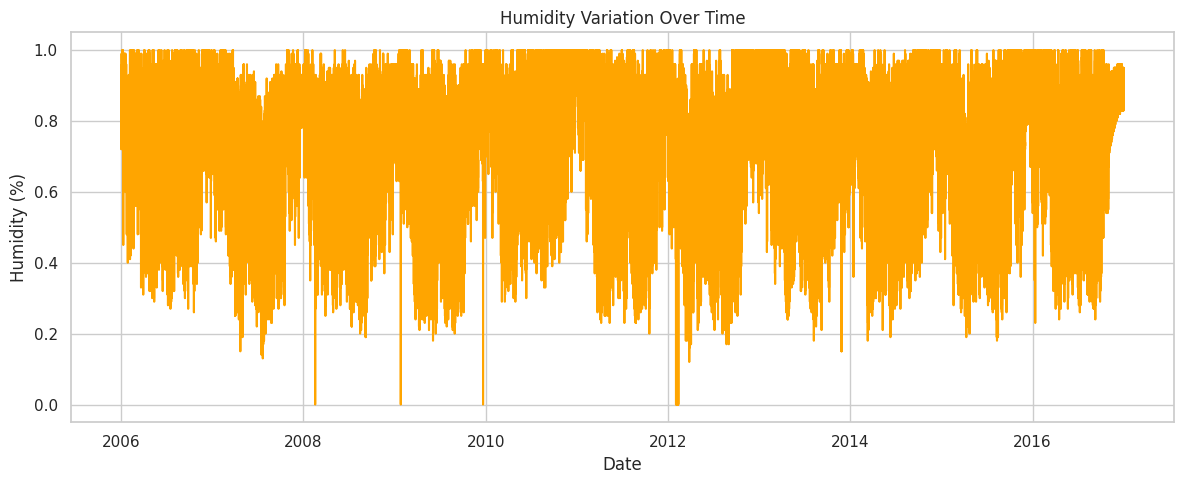

In [33]:
plt.figure(figsize=(12,5))
sns.lineplot(x='datetime', y='Humidity', data=df, color='orange')
plt.title('Humidity Variation Over Time')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

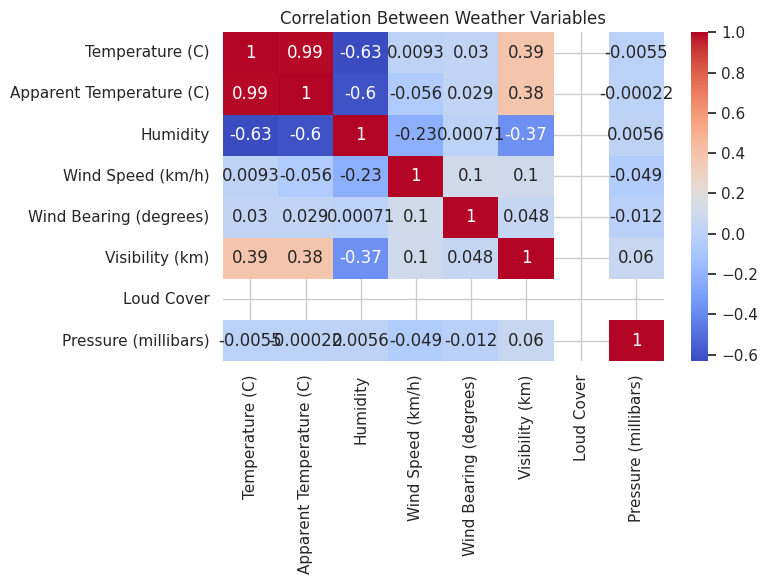

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather Variables')
plt.tight_layout()
plt.show()

In [35]:
from scipy import stats
import numpy as np
# Basic descriptive statistics using SciPy
temp = df['Temperature (C)'].dropna()
humidity = df['Humidity'].dropna()

mean_temp = np.mean(temp)
median_temp = np.median(temp)
mode_temp = stats.mode(temp, keepdims=True).mode[0]

print(f"Mean Temperature: {mean_temp:.2f}°C")
print(f"Median Temperature: {median_temp:.2f}°C")
print(f"Mode Temperature: {mode_temp:.2f}°C")


Mean Temperature: 11.93°C
Median Temperature: 12.00°C
Mode Temperature: 7.22°C


In [36]:
# Pearson correlation test
corr_coeff, p_value = stats.pearsonr(temp, humidity)

print(f"Pearson correlation coefficient: {corr_coeff:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print(" No significant correlation found.")


Pearson correlation coefficient: -0.632
P-value: 0.00000
The correlation is statistically significant (p < 0.05)


In [37]:
# t-test between two weather types
clear_days = df[df['Summary'] == 'Clear']['Temperature (C)']
overcast_days = df[df['Summary'] == 'Overcast']['Temperature (C)']

t_stat, p_val = stats.ttest_ind(clear_days, overcast_days, equal_var=False, nan_policy='omit')

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Significant difference in temperature between Clear and Overcast days.")
else:
    print("No significant temperature difference between Clear and Overcast days.")


T-statistic: 39.652
P-value: 0.00000
Significant difference in temperature between Clear and Overcast days.


### SciPy Statistical Insights

- Mean and median temperature provide central tendency of weather data.  
- Pearson’s correlation shows how temperature and humidity relate.  
- T-test compares mean temperatures across different weather conditions.  

These analyses show the power of SciPy in uncovering deeper insights beyond visualization.


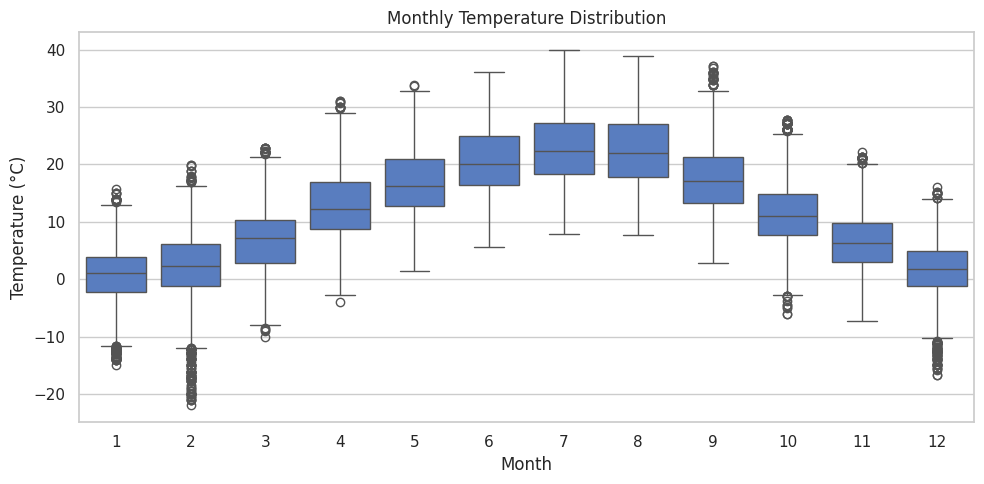

In [38]:
df['month'] = df.index.month
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='Temperature (C)', data=df)
plt.title('Monthly Temperature Distribution')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

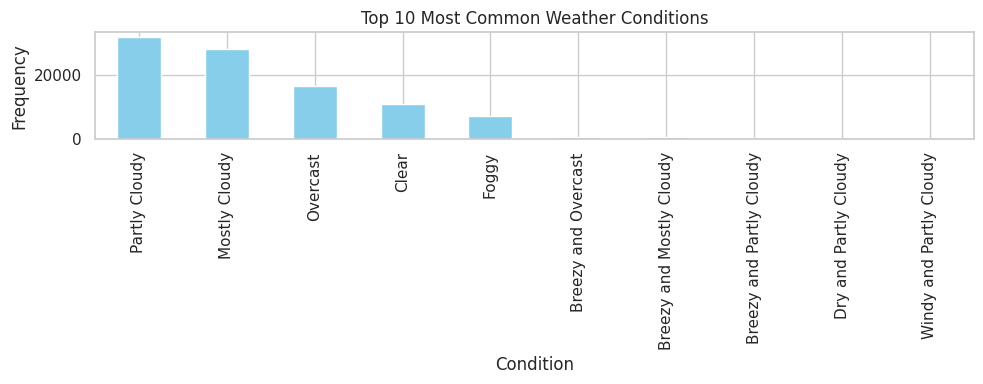

In [39]:
plt.figure(figsize=(10,4))
df['Summary'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Weather Conditions')
plt.xlabel('Condition')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipython-input-618346776.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df.resample('M').mean(numeric_only=True)


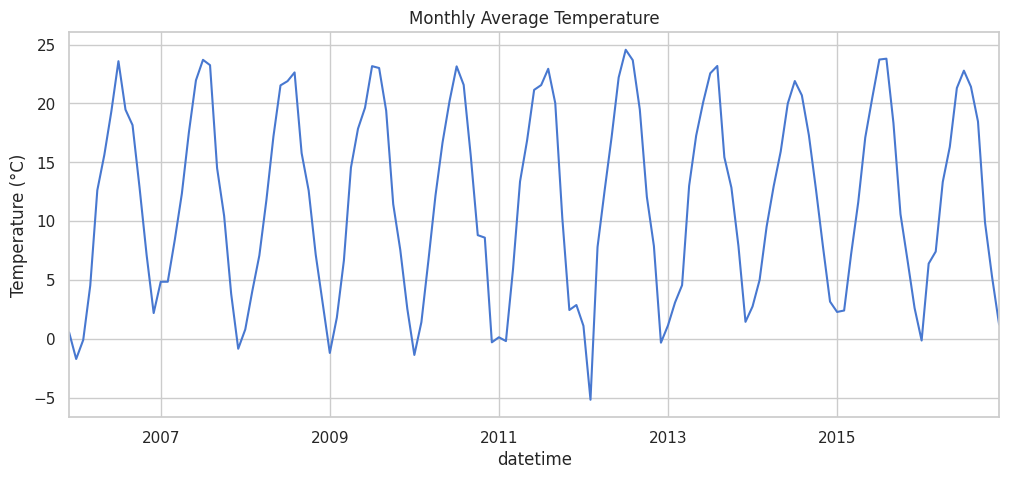

In [40]:
monthly_avg = df.resample('M').mean(numeric_only=True)
monthly_avg['Temperature (C)'].plot(figsize=(12,5), title='Monthly Average Temperature')
plt.ylabel('Temperature (°C)')
plt.show()


### Step 3: Insights & Conclusion

#### Key Insights
- Temperature and humidity are inversely correlated.  
- The dataset displays clear seasonal variations — higher temperatures during mid-year months.  
- The most common weather conditions are *Overcast*, *Clear*, and *Partly Cloudy*.  
- Correlation heatmap indicates strong relationships between temperature and apparent temperature.

#### Tools Used
- **Python Libraries:** pandas, seaborn, matplotlib  
- **Environment:** Google Colab  
- **Dataset:** Weather Dataset (Kaggle)

#### Conclusion
This project successfully demonstrates effective exploratory data analysis (EDA) of weather data using Python.  
Through visualizations and descriptive statistics, we discovered temperature trends, humidity fluctuations, and overall climatic behavior over time — without using any machine learning.
